# ResNet 18 Experiments

In [3]:
! pip install -q medmnist
! pip install -q medimeta
! pip install -q grad-cam

In [1]:
import medmnist

import importlib
import helpers as h
importlib.reload(h)

from medmnist import DermaMNIST, INFO
import torch
from torchvision.transforms import v2 as transforms, Compose
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

print(medmnist.__version__)

3.0.2


In [2]:
device = h.device.get_device()
print("Using device:", device)

Using device: cuda


In [3]:
# settings
DOWNLOAD = True
SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 2

SEED = 912742984

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

# print dataset info
info = INFO['dermamnist']

In [4]:
class_names = [info['label'][str(i)] for i in range(len(info['label']))]
class_names

['actinic keratoses and intraepithelial carcinoma',
 'basal cell carcinoma',
 'benign keratosis-like lesions',
 'dermatofibroma',
 'melanoma',
 'melanocytic nevi',
 'vascular lesions']

### ResNet 18

A baseline model: no data augmentation, train for 5 epochs

In [5]:
# transforms
basic_transform = Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


#### Basic Model

In [6]:

NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = basic_transform)
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

100%|██████████| 110/110 [00:03<00:00, 34.69it/s]


Epoch 0 | Train loss: 0.8315, acc: 0.713 | Val loss: 0.6412, acc: 0.780, macro AUC: 0.929


100%|██████████| 110/110 [00:01<00:00, 78.17it/s]


Epoch 1 | Train loss: 0.6215, acc: 0.781 | Val loss: 0.6145, acc: 0.769, macro AUC: 0.937


100%|██████████| 110/110 [00:01<00:00, 73.72it/s]


...

100%|██████████| 110/110 [00:01<00:00, 69.58it/s]


Epoch 3 | Train loss: 0.4624, acc: 0.836 | Val loss: 0.5814, acc: 0.796, macro AUC: 0.934


100%|██████████| 110/110 [00:01<00:00, 70.66it/s]


Epoch 4 | Train loss: 0.3743, acc: 0.862 | Val loss: 0.7170, acc: 0.761, macro AUC: 0.931


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

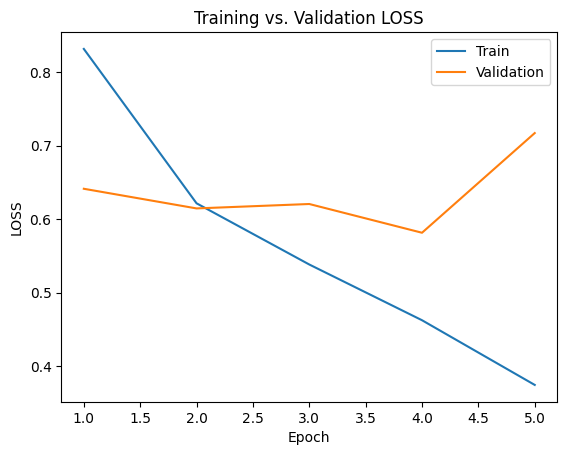

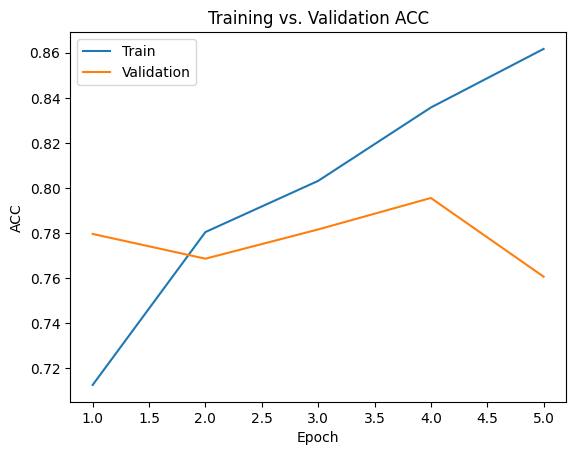

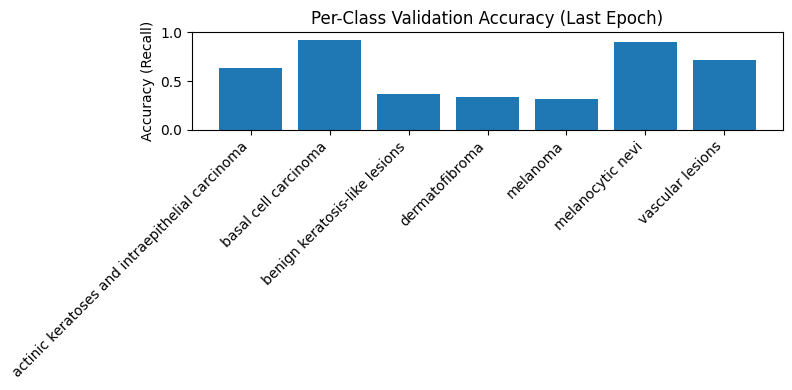

In [7]:
# create a fresh model (for reproducibility)
model = h.resnet.create_resnet(size=18)

# freeze all layers except classifier - not doing this anymore, since just training classifier doesn't work well
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history_model1 = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

h.metrics.plot_train_hist(train_history_model1, type='loss')
h.metrics.plot_train_hist(train_history_model1, type='acc')
h.metrics.plot_per_class_accuracy(train_history_model1, class_names=class_names)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

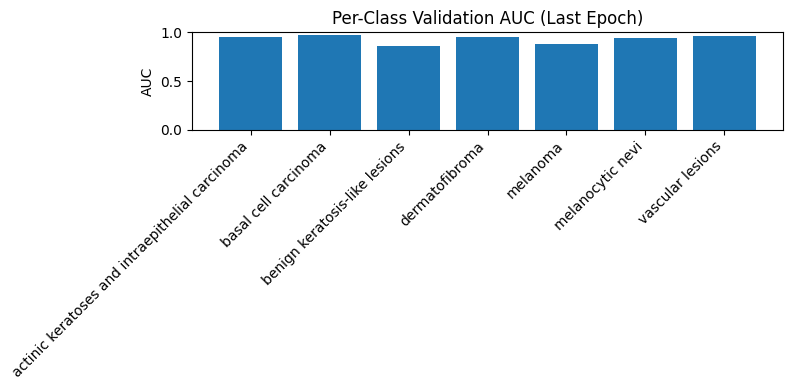

In [8]:
h.metrics.plot_per_class_auc(train_history_model1, class_names)

In [9]:
print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history_model1['val_acc'][-1])

Final AUC:
0.9309175970161448
Final validation accuracy:
0.7607178464606181


The baseline AUC is 0.92 and the baseline accuracy is 0.754. This model already beats both of them!

However, I will experiment more to see how high I can get it.

While the model looks like it is overfitting, let's see if that is a fluke by training for more epochs.

#### Basic Model 15 Epochs

100%|██████████| 110/110 [00:01<00:00, 75.62it/s]


Epoch 0 | Train loss: 0.8092, acc: 0.719 | Val loss: 0.8043, acc: 0.721, macro AUC: 0.905


100%|██████████| 110/110 [00:01<00:00, 75.71it/s]


Epoch 1 | Train loss: 0.6175, acc: 0.780 | Val loss: 0.6549, acc: 0.766, macro AUC: 0.933


100%|██████████| 110/110 [00:01<00:00, 77.28it/s]


...

100%|██████████| 110/110 [00:01<00:00, 72.71it/s]


Epoch 13 | Train loss: 0.0662, acc: 0.977 | Val loss: 1.0815, acc: 0.737, macro AUC: 0.927


100%|██████████| 110/110 [00:01<00:00, 73.48it/s]


Epoch 14 | Train loss: 0.0437, acc: 0.986 | Val loss: 1.5266, acc: 0.706, macro AUC: 0.911
Final AUC:
0.9114700849602343
Final validation accuracy:
0.7058823529411765


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

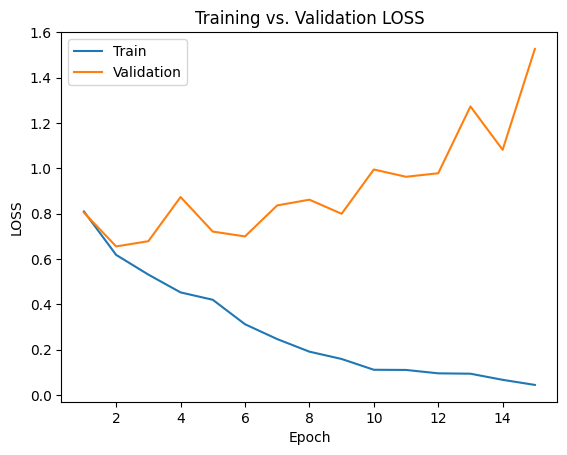

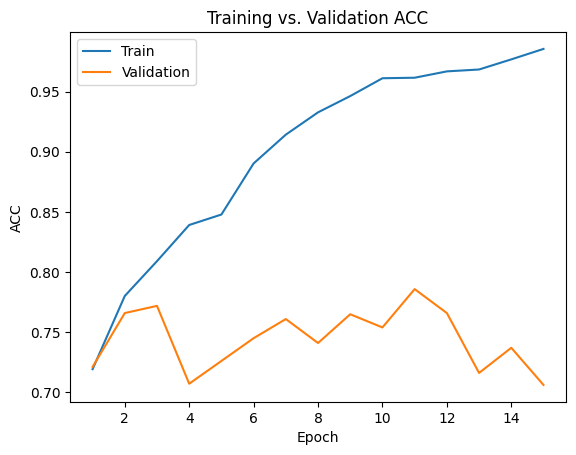

In [10]:
# longer epochs trained

NUM_EPOCHS = 15

model = h.resnet.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])
h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

That is definitely overfitting. There is no point in training beyond 5 epochs, so let's go with that.

Now, I will test data augmentation.

**AI Usage:** I asked ChatGPT to suggest some data augmentations I can do for dermatoscope images. I also asked it to generate PyTorch code for the augmentations it suggested (in the variable `data_augmentation_1`). This code is used below. I also uploaded the sample images back to ChatGPT and asked it to refine the data augmentations in follow-up prompts.

#### Data Augmentation 1 - This is the model reported in the progress report

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


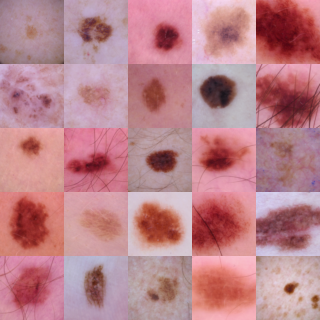

In [11]:
# data augmentations to test
data_augmentation_1 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    transforms.ColorJitter(
        brightness=0.05,            # ±5%
        contrast=0.05,              # ±5%
        saturation=0.05,            # ±5%
        hue=0.01                    # very small hue shift
    ),

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [12]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)
test_ds = DermaMNIST(split='test', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.resnet.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

100%|██████████| 110/110 [00:06<00:00, 16.14it/s]


Epoch 0 | Train loss: 0.8956, acc: 0.698 | Val loss: 0.7899, acc: 0.740, macro AUC: 0.869


100%|██████████| 110/110 [00:06<00:00, 16.44it/s]


Epoch 1 | Train loss: 0.7031, acc: 0.741 | Val loss: 0.6703, acc: 0.757, macro AUC: 0.934


100%|██████████| 110/110 [00:06<00:00, 17.08it/s]


...

Epoch 27 | Train loss: 0.5049, acc: 0.811 | Val loss: 0.5195, acc: 0.809, macro AUC: 0.955


100%|██████████| 110/110 [00:06<00:00, 16.55it/s]


Epoch 28 | Train loss: 0.4877, acc: 0.815 | Val loss: 0.5851, acc: 0.795, macro AUC: 0.945


100%|██████████| 110/110 [00:06<00:00, 16.64it/s]


Epoch 29 | Train loss: 0.4584, acc: 0.827 | Val loss: 0.5608, acc: 0.789, macro AUC: 0.948


Final AUC:
0.9476478098434891
Final validation accuracy:
0.7886340977068793


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

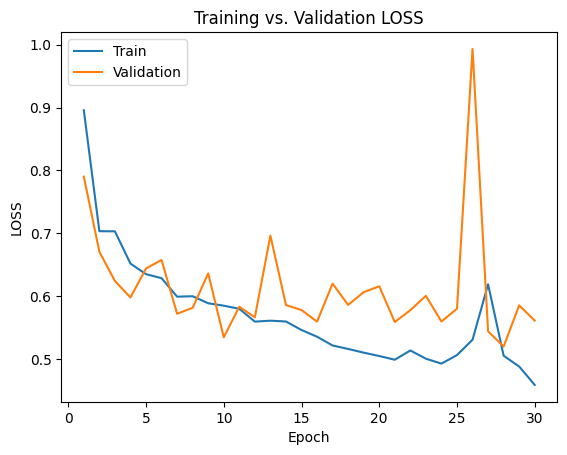

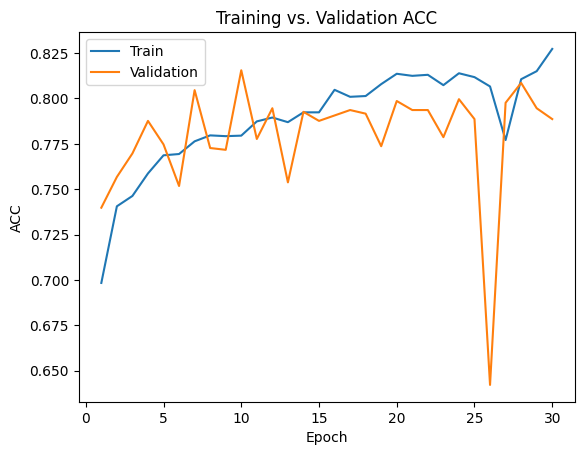

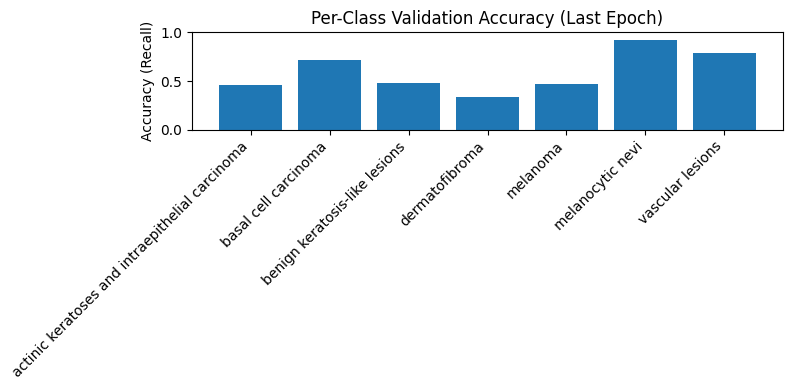

In [13]:
print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

h.metrics.plot_per_class_accuracy(train_history, class_names)

In [14]:
# evaluation on the test set
metrics_test_set = h.train.evaluate_model(model, test_loader, nn.CrossEntropyLoss(), len(class_names), device)
print("Overall Test Set Accuracy:", metrics_test_set['overall_acc'])
print("Overall Test Set AUC:", metrics_test_set['macro_auc'])

Overall Test Set Accuracy: 0.7990024937655861
Overall Test Set AUC: 0.9530780620448509


On these, it did not seem to overfit on 5 or 10 epochs.

It seems to start overfitting at around 25 epochs or so.

Let's try changing the augmentations a little.

#### Data Augmentation 2

Here, I remove the color transformations to see if that helps.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


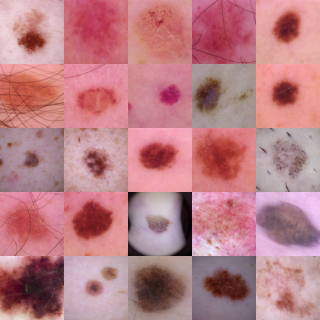

In [15]:
# data augmentations to test
data_augmentation_2 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    # BYE BYE!

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_2))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [16]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_2))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.resnet.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)


100%|██████████| 110/110 [00:03<00:00, 29.75it/s]


Epoch 0 | Train loss: 0.8318, acc: 0.708 | Val loss: 0.6662, acc: 0.751, macro AUC: 0.929


100%|██████████| 110/110 [00:03<00:00, 30.58it/s]


Epoch 1 | Train loss: 0.6976, acc: 0.744 | Val loss: 0.7133, acc: 0.742, macro AUC: 0.920


100%|██████████| 110/110 [00:03<00:00, 31.02it/s]


...

Epoch 27 | Train loss: 0.4537, acc: 0.828 | Val loss: 0.6259, acc: 0.795, macro AUC: 0.939


100%|██████████| 110/110 [00:03<00:00, 30.14it/s]


Epoch 28 | Train loss: 0.4426, acc: 0.828 | Val loss: 0.5768, acc: 0.791, macro AUC: 0.950


100%|██████████| 110/110 [00:03<00:00, 30.37it/s]


Epoch 29 | Train loss: 0.4323, acc: 0.836 | Val loss: 0.5709, acc: 0.799, macro AUC: 0.948


Final AUC:
0.9482503136701689
Final validation accuracy:
0.7986041874376869


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

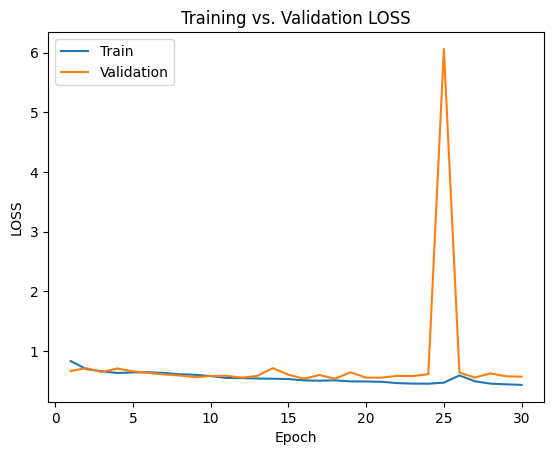

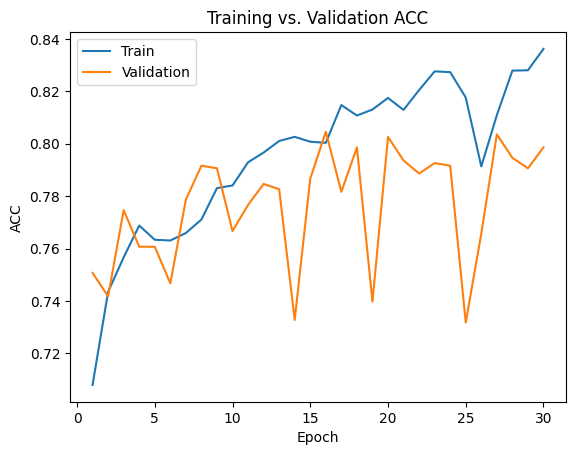

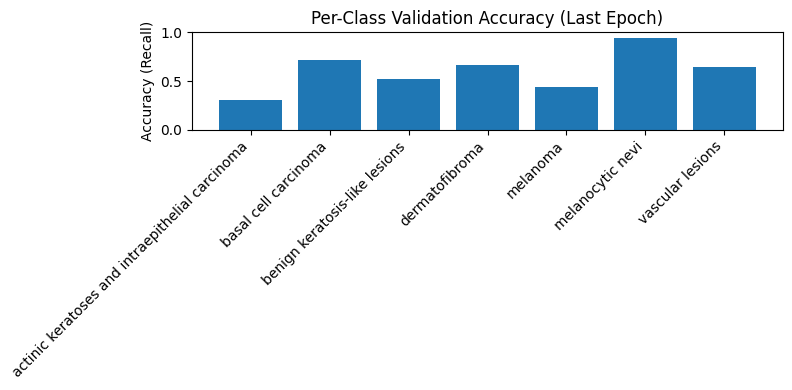

In [17]:
print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

h.metrics.plot_per_class_accuracy(train_history, class_names)

#### Data Augmentation 3

Here I remove some of the translations in case they are cropping parts of the borders of the lesions.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


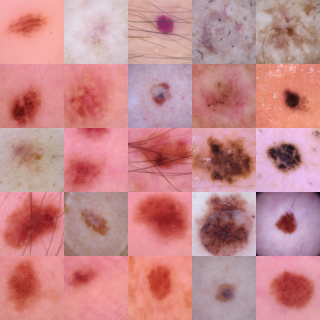

In [18]:
# data augmentations to test
data_augmentation_3 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    # transforms.RandomResizedCrop(
    #     size=64,
    #     scale=(0.95, 1.0),          # only small crops
    #     ratio=(0.95, 1.05)
    # ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    # BYE BYE!

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [19]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.resnet.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)


100%|██████████| 110/110 [00:02<00:00, 38.61it/s]


Epoch 0 | Train loss: 0.9004, acc: 0.700 | Val loss: 0.7896, acc: 0.695, macro AUC: 0.911


100%|██████████| 110/110 [00:02<00:00, 38.75it/s]


Epoch 1 | Train loss: 0.6937, acc: 0.748 | Val loss: 0.6450, acc: 0.766, macro AUC: 0.928


100%|██████████| 110/110 [00:02<00:00, 37.66it/s]


...

Epoch 27 | Train loss: 0.4244, acc: 0.836 | Val loss: 0.6299, acc: 0.792, macro AUC: 0.945


100%|██████████| 110/110 [00:02<00:00, 38.84it/s]


Epoch 28 | Train loss: 0.4233, acc: 0.838 | Val loss: 0.5279, acc: 0.807, macro AUC: 0.958


100%|██████████| 110/110 [00:02<00:00, 37.94it/s]


Epoch 29 | Train loss: 0.4125, acc: 0.840 | Val loss: 0.5598, acc: 0.805, macro AUC: 0.950


Final AUC:
0.9501337799834336
Final validation accuracy:
0.8045862412761715


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

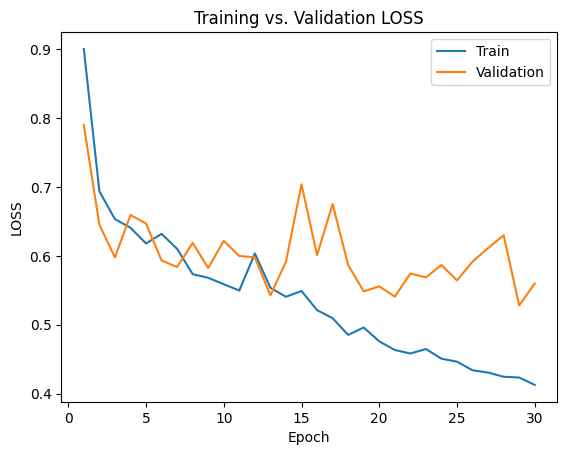

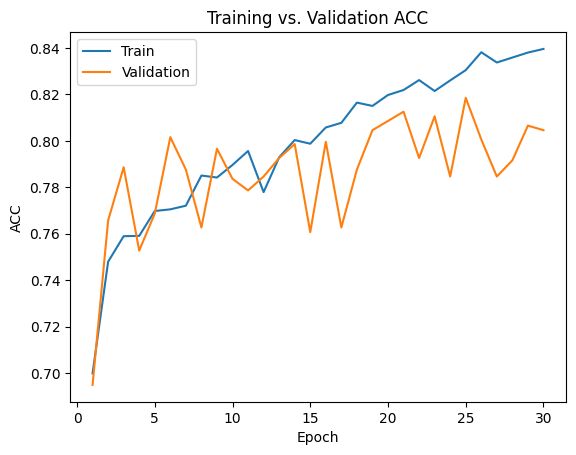

In [20]:
print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

Between all those data augmentations, it seems to be performing about the same.

Let's try adding attention.

In [21]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 60

model_se = h.resnet.create_resnet(size=18, use_se=True)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history_se = h.train.train_model(
    model_se, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model_se.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

100%|██████████| 110/110 [00:02<00:00, 38.29it/s]


Epoch 0 | Train loss: 0.8134, acc: 0.713 | Val loss: 0.7385, acc: 0.702, macro AUC: 0.928


100%|██████████| 110/110 [00:02<00:00, 37.84it/s]


Epoch 1 | Train loss: 0.6762, acc: 0.743 | Val loss: 0.7292, acc: 0.754, macro AUC: 0.919


100%|██████████| 110/110 [00:02<00:00, 37.70it/s]


...

Epoch 57 | Train loss: 0.1721, acc: 0.932 | Val loss: 0.6573, acc: 0.811, macro AUC: 0.953


100%|██████████| 110/110 [00:02<00:00, 39.26it/s]


Epoch 58 | Train loss: 0.1744, acc: 0.933 | Val loss: 0.6570, acc: 0.833, macro AUC: 0.951


100%|██████████| 110/110 [00:02<00:00, 37.42it/s]


Epoch 59 | Train loss: 0.1578, acc: 0.938 | Val loss: 0.7451, acc: 0.810, macro AUC: 0.947


Final AUC:
0.9474609632912615
Final validation accuracy:
0.8095712861415753


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

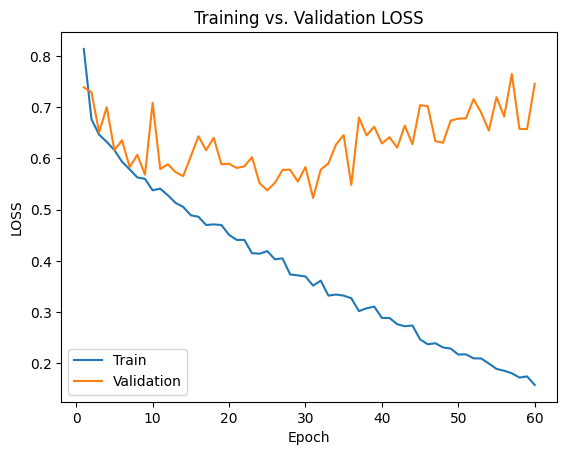

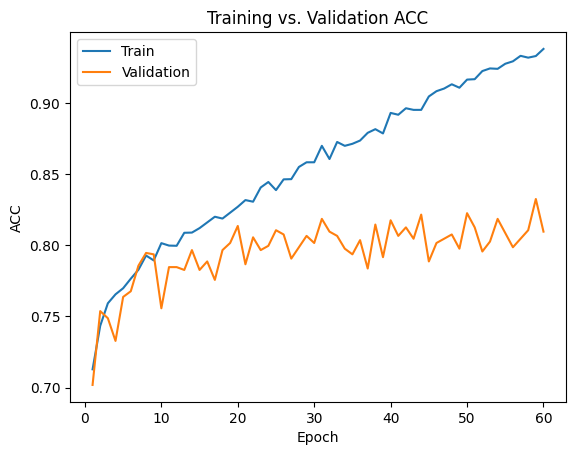

In [22]:
print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model_se, val_loader, device))

print("Final validation accuracy:")
print(train_history_se['val_acc'][-1])

h.metrics.plot_train_hist(train_history_se, type='loss')
h.metrics.plot_train_hist(train_history_se, type='acc')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

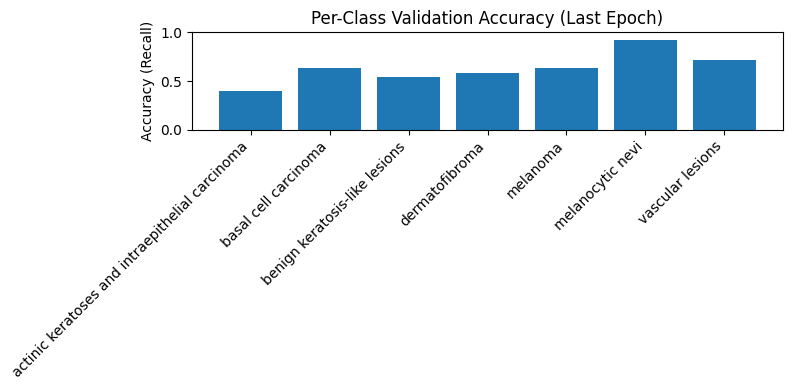

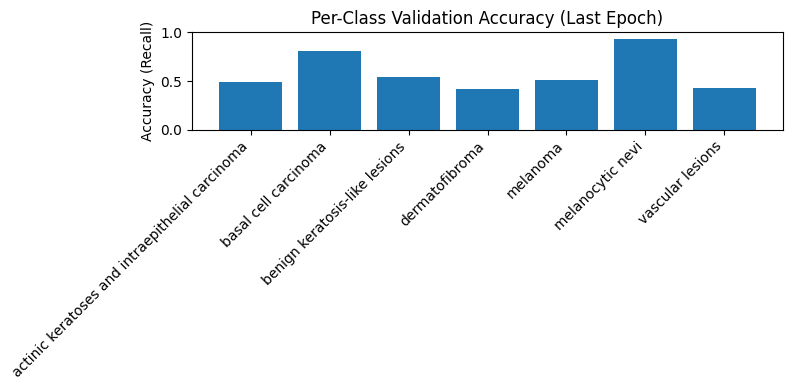

In [23]:
h.metrics.plot_per_class_accuracy(train_history_se, class_names)
h.metrics.plot_per_class_accuracy(train_history, class_names)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

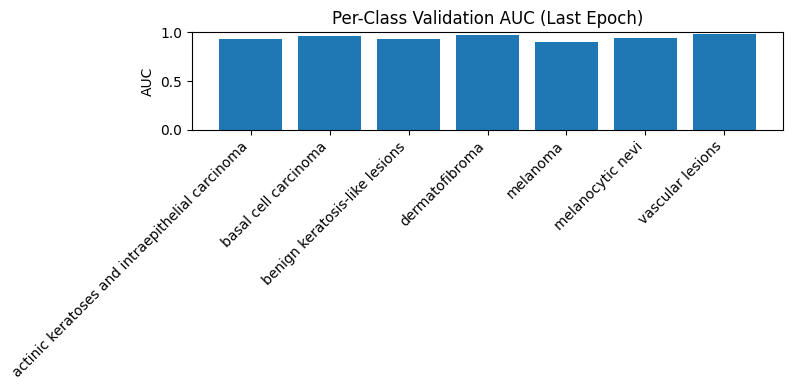

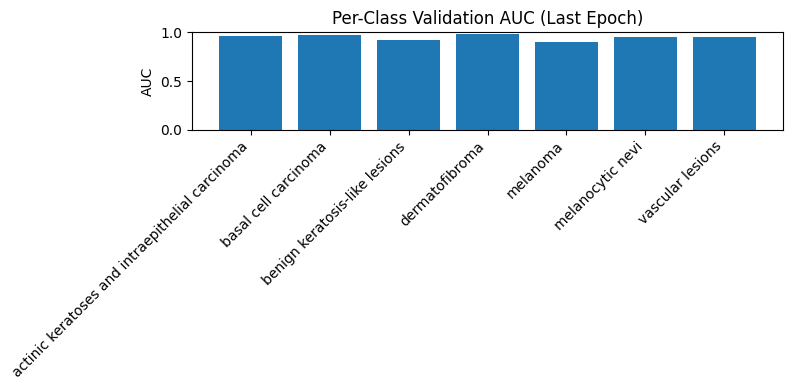

In [24]:
h.metrics.plot_per_class_auc(train_history_se, class_names)
h.metrics.plot_per_class_auc(train_history, class_names)